In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 10
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcY2QtZGVza1xEb2N1bWVudHNccmVwb3NcYWkxMDFcc3Jj'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\cd-desk\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1723003352.0, "C:\\Users\\cd-desk\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1723003352.0, "C:\\Users\\cd-desk\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1723003352.0, "C:\\Users\\cd-desk\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1723003350.0, "C:\\Users\\cd-desk\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1723003350.0, "C:\\Users\\cd-desk\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1723003350.0, "C:\\Users\\cd-desk\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1723003350.0, "C:\\Users\\cd-desk\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1723003350.0, "C:\\Users\\cd-desk\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1723003350.0, "C:\\Users\\cd-desk\\AppData\\Local\\Prog

C:\Users\cd-desk\AppData\Local\Temp\ipykernel_13308\3608473583.py:25: DeprecationWarning:

`set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`



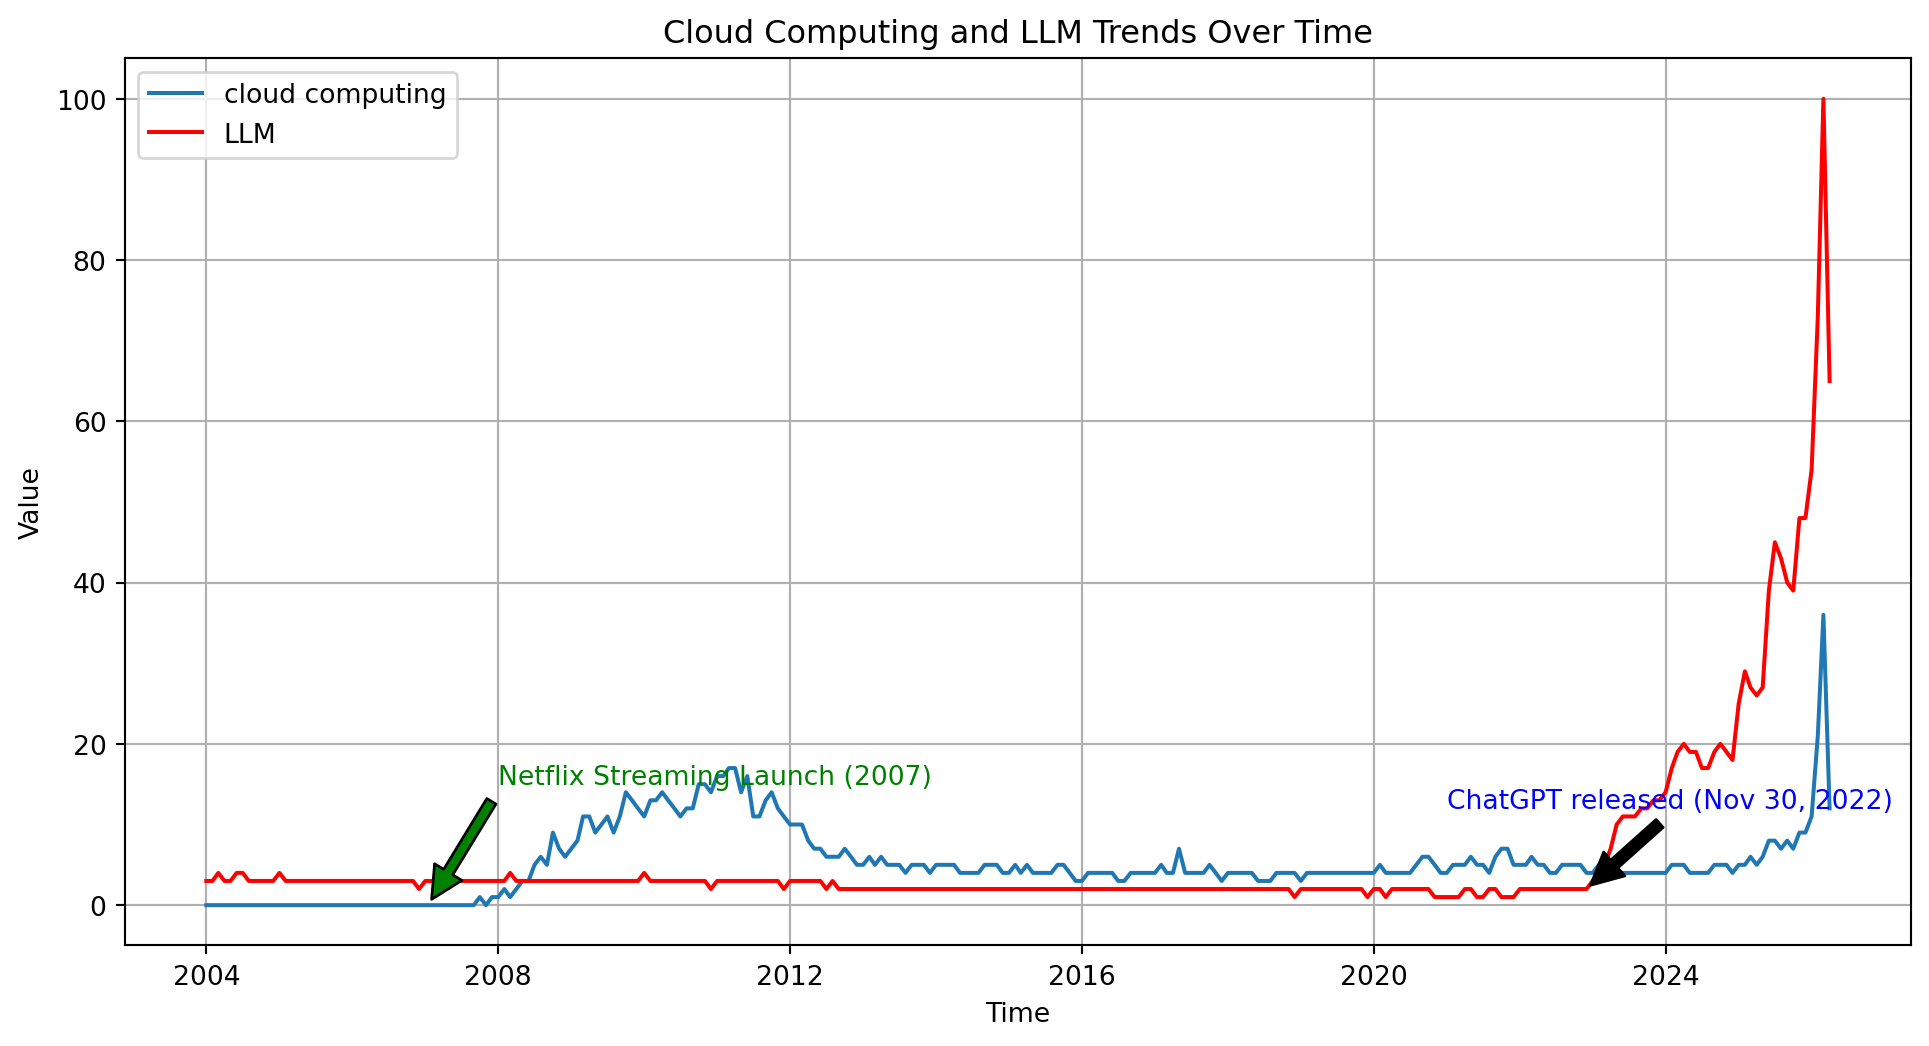

In [2]:
#| echo: false
import matplotlib.pyplot as plt
import io
import pandas as pd

# Data source: https://trends.google.com/explore?q=cloud%2520computing%2CLLM&date=all&geo=US
# Retrieved 23 Apr 26

vals = pd.read_csv(io.StringIO('''
Time,cloud computing,LLM
2004-01-01,0,3
2004-02-01,0,3
2004-03-01,0,4
2004-04-01,0,3
2004-05-01,0,3
2004-06-01,0,4
2004-07-01,0,4
2004-08-01,0,3
2004-09-01,0,3
2004-10-01,0,3
2004-11-01,0,3
2004-12-01,0,3
2005-01-01,0,4
2005-02-01,0,3
2005-03-01,0,3
2005-04-01,0,3
2005-05-01,0,3
2005-06-01,0,3
2005-07-01,0,3
2005-08-01,0,3
2005-09-01,0,3
2005-10-01,0,3
2005-11-01,0,3
2005-12-01,0,3
2006-01-01,0,3
2006-02-01,0,3
2006-03-01,0,3
2006-04-01,0,3
2006-05-01,0,3
2006-06-01,0,3
2006-07-01,0,3
2006-08-01,0,3
2006-09-01,0,3
2006-10-01,0,3
2006-11-01,0,3
2006-12-01,0,2
2007-01-01,0,3
2007-02-01,0,3
2007-03-01,0,3
2007-04-01,0,3
2007-05-01,0,3
2007-06-01,0,3
2007-07-01,0,3
2007-08-01,0,3
2007-09-01,0,3
2007-10-01,1,3
2007-11-01,0,3
2007-12-01,1,3
2008-01-01,1,3
2008-02-01,2,3
2008-03-01,1,4
2008-04-01,2,3
2008-05-01,3,3
2008-06-01,3,3
2008-07-01,5,3
2008-08-01,6,3
2008-09-01,5,3
2008-10-01,9,3
2008-11-01,7,3
2008-12-01,6,3
2009-01-01,7,3
2009-02-01,8,3
2009-03-01,11,3
2009-04-01,11,3
2009-05-01,9,3
2009-06-01,10,3
2009-07-01,11,3
2009-08-01,9,3
2009-09-01,11,3
2009-10-01,14,3
2009-11-01,13,3
2009-12-01,12,3
2010-01-01,11,4
2010-02-01,13,3
2010-03-01,13,3
2010-04-01,14,3
2010-05-01,13,3
2010-06-01,12,3
2010-07-01,11,3
2010-08-01,12,3
2010-09-01,12,3
2010-10-01,15,3
2010-11-01,15,3
2010-12-01,14,2
2011-01-01,16,3
2011-02-01,16,3
2011-03-01,17,3
2011-04-01,17,3
2011-05-01,14,3
2011-06-01,16,3
2011-07-01,11,3
2011-08-01,11,3
2011-09-01,13,3
2011-10-01,14,3
2011-11-01,12,3
2011-12-01,11,2
2012-01-01,10,3
2012-02-01,10,3
2012-03-01,10,3
2012-04-01,8,3
2012-05-01,7,3
2012-06-01,7,3
2012-07-01,6,2
2012-08-01,6,3
2012-09-01,6,2
2012-10-01,7,2
2012-11-01,6,2
2012-12-01,5,2
2013-01-01,5,2
2013-02-01,6,2
2013-03-01,5,2
2013-04-01,6,2
2013-05-01,5,2
2013-06-01,5,2
2013-07-01,5,2
2013-08-01,4,2
2013-09-01,5,2
2013-10-01,5,2
2013-11-01,5,2
2013-12-01,4,2
2014-01-01,5,2
2014-02-01,5,2
2014-03-01,5,2
2014-04-01,5,2
2014-05-01,4,2
2014-06-01,4,2
2014-07-01,4,2
2014-08-01,4,2
2014-09-01,5,2
2014-10-01,5,2
2014-11-01,5,2
2014-12-01,4,2
2015-01-01,4,2
2015-02-01,5,2
2015-03-01,4,2
2015-04-01,5,2
2015-05-01,4,2
2015-06-01,4,2
2015-07-01,4,2
2015-08-01,4,2
2015-09-01,5,2
2015-10-01,5,2
2015-11-01,4,2
2015-12-01,3,2
2016-01-01,3,2
2016-02-01,4,2
2016-03-01,4,2
2016-04-01,4,2
2016-05-01,4,2
2016-06-01,4,2
2016-07-01,3,2
2016-08-01,3,2
2016-09-01,4,2
2016-10-01,4,2
2016-11-01,4,2
2016-12-01,4,2
2017-01-01,4,2
2017-02-01,5,2
2017-03-01,4,2
2017-04-01,4,2
2017-05-01,7,2
2017-06-01,4,2
2017-07-01,4,2
2017-08-01,4,2
2017-09-01,4,2
2017-10-01,5,2
2017-11-01,4,2
2017-12-01,3,2
2018-01-01,4,2
2018-02-01,4,2
2018-03-01,4,2
2018-04-01,4,2
2018-05-01,4,2
2018-06-01,3,2
2018-07-01,3,2
2018-08-01,3,2
2018-09-01,4,2
2018-10-01,4,2
2018-11-01,4,2
2018-12-01,4,1
2019-01-01,3,2
2019-02-01,4,2
2019-03-01,4,2
2019-04-01,4,2
2019-05-01,4,2
2019-06-01,4,2
2019-07-01,4,2
2019-08-01,4,2
2019-09-01,4,2
2019-10-01,4,2
2019-11-01,4,2
2019-12-01,4,1
2020-01-01,4,2
2020-02-01,5,2
2020-03-01,4,1
2020-04-01,4,2
2020-05-01,4,2
2020-06-01,4,2
2020-07-01,4,2
2020-08-01,5,2
2020-09-01,6,2
2020-10-01,6,2
2020-11-01,5,1
2020-12-01,4,1
2021-01-01,4,1
2021-02-01,5,1
2021-03-01,5,1
2021-04-01,5,2
2021-05-01,6,2
2021-06-01,5,1
2021-07-01,5,1
2021-08-01,4,2
2021-09-01,6,2
2021-10-01,7,1
2021-11-01,7,1
2021-12-01,5,1
2022-01-01,5,2
2022-02-01,5,2
2022-03-01,6,2
2022-04-01,5,2
2022-05-01,5,2
2022-06-01,4,2
2022-07-01,4,2
2022-08-01,5,2
2022-09-01,5,2
2022-10-01,5,2
2022-11-01,5,2
2022-12-01,4,2
2023-01-01,4,3
2023-02-01,5,3
2023-03-01,4,5
2023-04-01,4,7
2023-05-01,4,10
2023-06-01,4,11
2023-07-01,4,11
2023-08-01,4,11
2023-09-01,4,12
2023-10-01,4,12
2023-11-01,4,13
2023-12-01,4,13
2024-01-01,4,14
2024-02-01,5,17
2024-03-01,5,19
2024-04-01,5,20
2024-05-01,4,19
2024-06-01,4,19
2024-07-01,4,17
2024-08-01,4,17
2024-09-01,5,19
2024-10-01,5,20
2024-11-01,5,19
2024-12-01,4,18
2025-01-01,5,25
2025-02-01,5,29
2025-03-01,6,27
2025-04-01,5,26
2025-05-01,6,27
2025-06-01,8,39
2025-07-01,8,45
2025-08-01,7,43
2025-09-01,8,40
2025-10-01,7,39
2025-11-01,9,48
2025-12-01,9,48
2026-01-01,11,54
2026-02-01,21,73
2026-03-01,36,100
2026-04-01,12,65
'''), parse_dates=['Time'])

## Gemini generated

plt.figure(figsize=(12, 6))
plt.plot(vals['Time'], vals['cloud computing'], label='cloud computing')
plt.plot(vals['Time'], vals['LLM'], label='LLM', color='red')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Cloud Computing and LLM Trends Over Time')
plt.legend()
plt.grid(True)

# Add annotation for ChatGPT release
# Found this one from https://en.wikipedia.org/wiki/ChatGPT

chatgpt_release_date = pd.to_datetime('2022-11-30')
llm_value_at_release = vals[vals['Time'] <= chatgpt_release_date]['LLM'].iloc[-1]

plt.annotate(
    'ChatGPT released (Nov 30, 2022)', 
    xy=(chatgpt_release_date, llm_value_at_release), 
    xytext=(pd.to_datetime('2021-01-01'), llm_value_at_release + 10), # Adjust xytext for better visibility
    arrowprops=dict(facecolor='black', shrink=0.05), 
    fontsize=10, 
    color='blue'
)

# Add annotation for Netflix streaming launch
# Found this one from https://en.wikipedia.org/wiki/History_of_cloud_computing#2000s

netflix_streaming_date = pd.to_datetime('2007-01-15') # Approximate date
cloud_computing_value_at_netflix_launch = vals[vals['Time'] <= netflix_streaming_date]['cloud computing'].iloc[-1]

plt.annotate(
    'Netflix Streaming Launch (2007)', 
    xy=(netflix_streaming_date, cloud_computing_value_at_netflix_launch), 
    xytext=(pd.to_datetime('2008-01-01'), cloud_computing_value_at_netflix_launch + 15), # Adjust xytext for better visibility
    arrowprops=dict(facecolor='green', shrink=0.05), 
    fontsize=10, 
    color='green'
)

plt.show()